In [3]:
# =========================
# SIMPLE RNN - GOOGLE STOCK PRICE PREDICTION
# =========================

# Kütüphaneler
!pip install yfinance tensorflow -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout



In [4]:

# =========================
# VERIYI CEK
# =========================

df = yf.download("GOOG", start="2018-01-01", end="2024-01-01")

print(df.head())




/tmp/ipykernel_5051/1477821391.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("GOOG", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker           GOOG       GOOG       GOOG       GOOG      GOOG
Date                                                            
2018-01-02  52.816380  52.912590  51.835930  51.990163  24752000
2018-01-03  53.683266  53.872213  52.727611  52.782163  28604000
2018-01-04  53.877666  54.233249  53.758743  53.957017  20092000
2018-01-05  54.662724  54.762903  54.155387  54.254575  25582000
2018-01-08  54.896309  55.111045  54.632476  54.662726  20952000


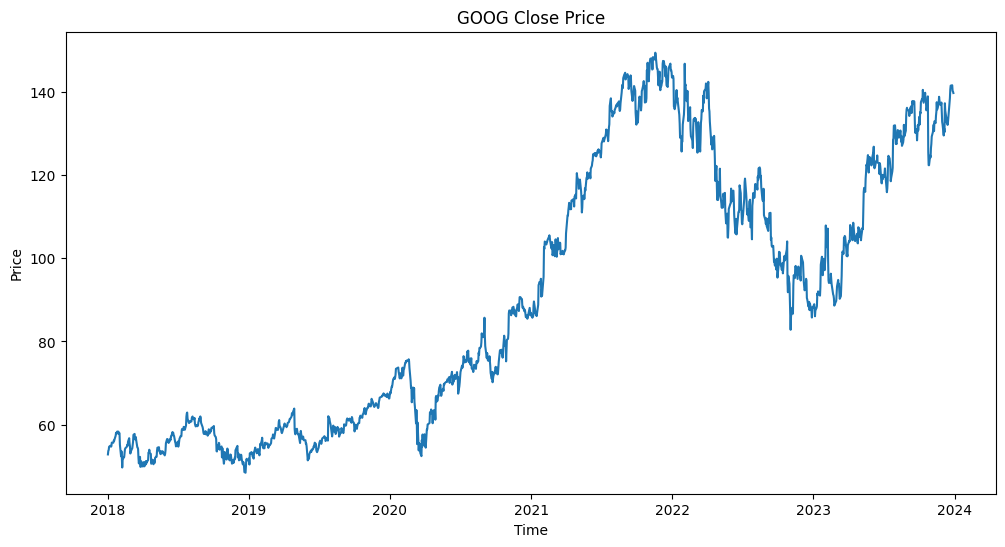

In [5]:
# =========================
# CLOSE PRICE
# =========================

data = df[['Close']]

plt.figure(figsize=(12,6))
plt.plot(data)
plt.title("GOOG Close Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()




In [6]:
# =========================
# TRAIN / TEST
# =========================

train_length = int(len(data) * 0.7)

train_data = data[:train_length]
test_data = data[train_length:]



In [7]:

# =========================
# SCALING
# =========================

scaler = MinMaxScaler(feature_range=(0,1))

scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)




In [8]:
# =========================
# SEQUENCE OLUSTUR
# =========================

x_train = []
y_train = []

step = 50

for i in range(step, len(scaled_train)):
    x_train.append(scaled_train[i-step:i, 0])
    y_train.append(scaled_train[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)




X_train shape: (1006, 50, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,751 (49.81 KB)

 Trainable params: 12,751 (49.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.2515
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0943
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0544
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0341
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0307
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0223
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0191
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0187
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0162
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0158
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


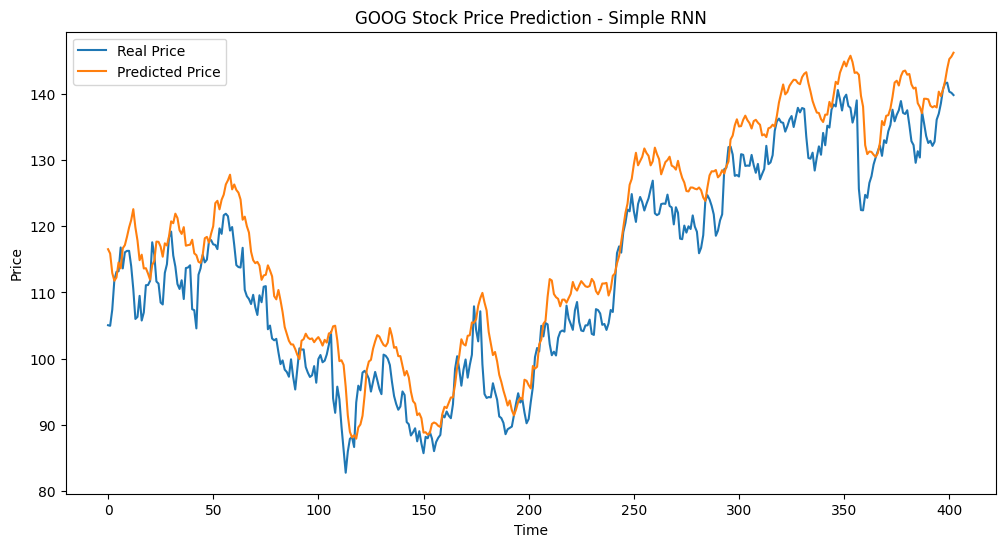

Model kaydedildi.


In [9]:
# =========================
# RESHAPE
# =========================

X_train = np.reshape(
    x_train,
    (x_train.shape[0], x_train.shape[1], 1)
)

print("X_train shape:", X_train.shape)


# =========================
# SIMPLE RNN MODEL
# =========================

model = Sequential()

model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dropout(0.2))

model.add(
    SimpleRNN(
        units=50,
        return_sequences=True
    )
)

model.add(Dropout(0.2))

model.add(
    SimpleRNN(
        units=50
    )
)

model.add(Dropout(0.2))

model.add(Dense(units=1))


# =========================
# COMPILE
# =========================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


# =========================
# TRAIN
# =========================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)


# =========================
# TEST SET HAZIRLA
# =========================

x_test = []
y_test = []

for i in range(step, len(scaled_test)):
    x_test.append(scaled_test[i-step:i, 0])
    y_test.append(scaled_test[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

X_test = np.reshape(
    x_test,
    (x_test.shape[0], x_test.shape[1], 1)
)


# =========================
# TAHMIN
# =========================

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

real_values = scaler.inverse_transform(
    y_test.reshape(-1,1)
)


# =========================
# GRAFIK
# =========================

plt.figure(figsize=(12,6))

plt.plot(real_values, label='Real Price')
plt.plot(predictions, label='Predicted Price')

plt.title("GOOG Stock Price Prediction - Simple RNN")

plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()


# =========================
# MODEL KAYDET
# =========================

model.save("SimpleRNN_GOOG.h5")

print("Model kaydedildi.")

* Model genel trendi başarılı şekilde öğrenmiş. Tahmin çizgisi gerçek veriyi büyük ölçüde takip ediyor.
* Loss değerinin düzenli düşmesi modelin stabil öğrendiğini gösteriyor.

Başlangıç ve son loss:

0.2515 \rightarrow 0.0158

* Ani yükseliş ve düşüşlerde tahminler biraz gecikiyor. Bu durum Simple RNN’lerde normaldir.
* Dropout katmanları sayesinde ciddi bir overfitting görünmüyor.
* Modelde geçmiş 50 gün kullanılarak sonraki gün tahmin edilmiştir (step=50).
* Veriler MinMaxScaler ile normalize edilmiştir, bu RNN’in daha stabil öğrenmesini sağlar.
* return_sequences=True kullanılarak sequence bilgisi sonraki RNN katmanına aktarılmıştır.
* Toplam parametre sayısı düşük olduğu için model hızlı ve hafif çalışmaktadır.
* Daha iyi sonuç için ileride:
    * LSTM / GRU kullanılabilir
    * validation loss eklenebilir
    * epoch artırılabilir
    * RMSE / MAE metriği hesaplanabilir.